# Model Training: Overall-Aggregated Dataset

## Introduction

This notebook documents a second iteration of the machine learning modeling process, designed to improve upon the results from the previous analysis. The prior attempt, which utilized a hybrid dataset with both yearly and overall-aggregated parameters, culminated in a model with no practical utility for hydrologic simulation, achieving an **Average Nash-Sutcliffe Efficiency (NSE) astronomically low** on the hold-out storm events.

A key hypothesis for that poor performance is that aggregating some watersheds on a yearly basis, given the limited data, may have introduced more noise than signal, preventing the models from learning stable, generalizable patterns.

This analysis tests that hypothesis by employing a simplified and potentially more robust dataset where **all watersheds are aggregated using a single, long-term average**. The goal is to determine if this more stable dataset can yield a more accurate and reliable predictive model.

## Modeling Strategy

The core modeling strategy remains consistent with the previous workflow, but is now focused on the most promising approaches identified.

* **Candidate Models:** Based on the results from the initial model comparison, we will focus exclusively on the two best-performing architectures: **Elastic Net** and **Random Forest**.

* **Target and Preprocessing:** We will continue to model the **log-transformed** target variables ($\log(T_c)$ and $\log(R)$) to handle their skewed distributions. Tailored preprocessing pipelines will be used:
    * **For Elastic Net:** A pipeline including the feature transformations (Log/Box-Cox) identified in the EDA, followed by Z-score standardization.
    * **For Random Forest:** A simpler pipeline containing only Z-score standardization.

## Model Training and Evaluation Workflow

We will follow the same robust, multi-step process to ensure our model evaluation is unbiased and reliable. Two separate modeling pipelines will be developed, one for predicting $\log(T_c)$ and one for $\log(R)$.

1.  **Data Splitting:** The dataset will be split into a **training/validation pool (80% of watersheds)** and a final **hold-out test set (20% of watersheds)**. This split is performed based on `ws_id` to prevent data leakage.

2.  **Pipeline Construction:** `scikit-learn` Pipelines will be used to bundle the appropriate preprocessing and modeling steps for each algorithm.

3.  **Model Selection via Cross-Validation**: Given the limited number of data points (one for each watershed), we will use **Leave-One-Out Cross-Validation (LOOCV)**. This method provides the most robust and data-efficient performance estimate by training the model on all but one data point and testing it on the single remaining point, repeating the process for every data point in the training pool. This approach will be used to evaluate the performance of both the Elastic Net and Random Forest models.

4.  **Final Model Training:** The best-performing model architecture for each target will be re-trained one last time on the **entire training/validation pool**.

5.  **Final Evaluation:** This final, retrained model will be evaluated on the **untouched hold-out test set** to provide a definitive, unbiased assessment of its ability to generalize, and subsequently used for hydrologic simulation validation.

## Performance Metrics
The models will be compared using a standard set of regression and hydrological metrics, including:
* Root Mean Squared Error (RMSE)
* R-squared ($R^2$)
* Nash-Sutcliffe Efficiency (NSE)
* Mean Absolute Percentage Error (MAPE) of Peak Flow
* Bias of Peak Flow
* Mean Absolute Error (MAE) of Time to Peak
* Bias of Total Volume

**Note**:

Before running this notebook, a preprocess step was taken to compute and save the cell area for each watershed. The source file is [available here](../../src/hydrology/compute_cell_area.py).

In [ ]:
# Set root folder for the project
from pathlib import Path

try:
  from google.colab import drive
  drive.mount('/content/drive')
  PROJECT_ROOT = Path.cwd() / "drive/My Drive/Data Science Project/ML-ModClark-IUH-Model"
  print(f"Project Root: {PROJECT_ROOT}")
except:
  # Project Root
  PROJECT_ROOT = Path.cwd().parent.parent
  print(f"Project Root: {PROJECT_ROOT}")

Project Root: /Users/alan/Data Science Projects/ML-ModClark-IUH-Model


In [ ]:
# Add custom modules to the path
import sys

# Custom Modules
sys.path.append(str(PROJECT_ROOT / 'src'))

In [ ]:
# Load dataframes
import pandas as pd

# Machine Learning Data
df_master_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/df_master_watershed_only.csv"
df_master = pd.read_csv(df_master_path, dtype={'ws_id':str})

# Feature Transformation Recommendations
df_recommendations_path = PROJECT_ROOT / "data/gold/tabular/machine_learning/feature_transformation_recommendations.csv"
df_recommendations = pd.read_csv(df_recommendations_path)

In [ ]:
import numpy as np
# Create New Column Developed Vs Undeveloped Ration
# Calculate undeveloped percentage as sum of non-developed land cover types
undeveloped_cols = ['pct_forest', 'pct_agriculture', 'pct_grass_scrub',
                    'pct_wetlands', 'pct_water', 'pct_barren']
df_master['pct_undeveloped'] = df_master[undeveloped_cols].sum(axis=1)

# Calculate the ratio: pct_developed / pct_undeveloped
df_master['developed_vs_undeveloped_ratio'] = np.where(
    df_master['pct_undeveloped'] > 0,
    df_master['pct_developed'] / df_master['pct_undeveloped'],
    0  # Set to 0 if undeveloped percentage is 0
)

print("New column 'developed_vs_undeveloped_ratio' added.")

New column 'developed_vs_undeveloped_ratio' added.


In [ ]:
# Load custom functions
from utils.utils import measure_execution_time
from hydrology.modclark_model import ModClarkModel
from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm

In [ ]:
# Create necessary functions
import joblib

# Save trained model
def save_model(model, model_name):
  try:
    model_dir = PROJECT_ROOT / 'models'
    model_dir.mkdir(exist_ok=True)
    joblib.dump(model, model_dir / model_name)
    print("Model saved successfully.")
  except Exception as e:
    print("Failed to save model: ",e)

## 1. Data Splitting

--- Splitting data into Training Pool and Hold-Out Test Set ---

--- Split Summary ---
Total unique watersheds: 112
Watersheds in Training/Validation Pool: 89 (~80%)
Watersheds in Hold-Out Test Set: 23 (~20%)
------------------------------
Total data points: 112
Data points in Training/Validation Pool: 89
Data points in Hold-Out Test Set: 23

Verification successful: No watershed overlap between sets. ✅



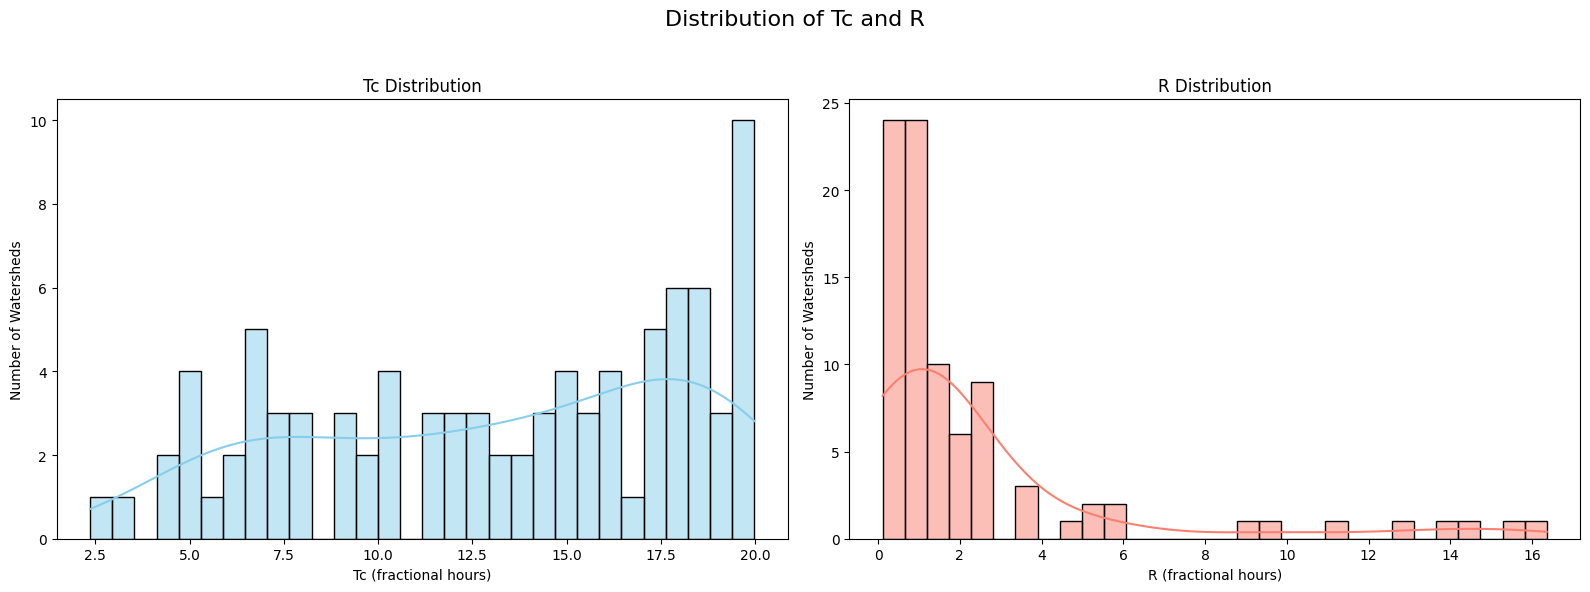

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assume df_master is a pre-existing pandas DataFrame ---
# It must contain a 'ws_id' column.

#-------------------------------------------------------------------------------
## 1. Data Splitting (Simple Random Split)
#-------------------------------------------------------------------------------
print("--- Splitting data into Training Pool and Hold-Out Test Set ---")

# Perform the split with 80/20 ratio
df_train_pool, df_test = train_test_split(
    df_master,
    test_size=0.2,
    random_state=42
)

# Get the unique watershed IDs for each set
train_pool_ws_ids = df_train_pool['ws_id'].unique()
test_set_ws_ids = df_test['ws_id'].unique()

# --- Summary of the Split ---
print("\n--- Split Summary ---")
print(f"Total unique watersheds: {len(df_master['ws_id'].unique())}")
print(f"Watersheds in Training/Validation Pool: {len(train_pool_ws_ids)} (~80%)")
print(f"Watersheds in Hold-Out Test Set: {len(test_set_ws_ids)} (~20%)")
print("-" * 30)
print(f"Total data points: {len(df_master)}")
print(f"Data points in Training/Validation Pool: {len(df_train_pool)}")
print(f"Data points in Hold-Out Test Set: {len(df_test)}")

# Verify that there are no overlapping watersheds between the two sets
assert len(np.intersect1d(train_pool_ws_ids, test_set_ws_ids)) == 0
print("\nVerification successful: No watershed overlap between sets. ✅\n")

# Tc and R Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Tc and R', fontsize=16)

# Plot for CV of Tc
sns.histplot(df_train_pool['tc'], ax=axes[0], kde=True, color='skyblue', bins=30)
axes[0].set_title('Tc Distribution')
axes[0].set_xlabel('Tc (fractional hours)')
axes[0].set_ylabel('Number of Watersheds')

# Plot for CV of R
sns.histplot(df_train_pool['r'], ax=axes[1], kde=True, color='salmon', bins=30)
axes[1].set_title('R Distribution')
axes[1].set_xlabel('R (fractional hours)')
axes[1].set_ylabel('Number of Watersheds')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 2. Pipeline Constructor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# --- Assume df_master, and df_recommendations are pre-existing ---

#-------------------------------------------------------------------------------
## 2. Pipeline Construction (Dynamic and Robust to Zeros)
#-------------------------------------------------------------------------------

# --- Define custom classes and functions for robust transformations ---

def log_transform_safe(x):
    """Adds a small constant to handle log(0) issues."""
    epsilon = 1e-6
    return np.log(x + epsilon)

class SafePowerTransformer(BaseEstimator, TransformerMixin):
    """
    A wrapper for PowerTransformer that adds a small constant to handle
    zero values before applying the Box-Cox transformation.
    """
    def __init__(self, method='box-cox', standardize=True):
        self.method = method
        self.standardize = standardize
        self.epsilon = 1e-6
        self.transformer_ = PowerTransformer(method=self.method, standardize=self.standardize)

    def fit(self, X, y=None):
        # Shift data by epsilon before fitting
        X_shifted = X + self.epsilon
        self.transformer_.fit(X_shifted)
        return self

    def transform(self, X):
        # Shift data by epsilon before transforming
        X_shifted = X + self.epsilon
        return self.transformer_.transform(X_shifted)

# --- Main pipeline creation function ---

print("--- Building Preprocessing Pipelines Based on Recommendations ---")

def create_preprocessor_for_target(target_name, recommendations_df, feature_list):
    """Builds a preprocessing pipeline for a specific target variable."""

    rec_target = recommendations_df[recommendations_df['Target'] == target_name]

    log_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Log(x)']['Feature'].tolist() if f in feature_list]
    boxcox_features = [f for f in rec_target[rec_target['Best_Transform_Type'] == 'Box-Cox(x)']['Feature'].tolist() if f in feature_list]

    transformer_steps = []
    if log_features:
        transformer_steps.append(
            ('log', FunctionTransformer(log_transform_safe), log_features)
        )
    if boxcox_features:
        # Use the new SafePowerTransformer to handle potential zeros
        transformer_steps.append(
            ('power', SafePowerTransformer(method='box-cox'), boxcox_features)
        )

    feature_transformer = ColumnTransformer(
        transformers=transformer_steps,
        remainder='passthrough',
        force_int_remainder_cols=False
    )

    preprocessor_pipeline = Pipeline(steps=[
        ('feature_transformer', feature_transformer),
        ('scaler', StandardScaler())
    ])

    return preprocessor_pipeline

# --- Create the specific pipelines for TC and R ---
col_names = df_master.columns.tolist()
remove_cols = ['ws_id','year','tc','r']
features_to_analyze = [f for f in col_names if f not in remove_cols]
linear_preprocessor_tc = create_preprocessor_for_target('TC', df_recommendations, features_to_analyze)
linear_preprocessor_r = create_preprocessor_for_target('R', df_recommendations, features_to_analyze)


# --- Summary of Linear Pipelines ---
print("\n✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:")
print(linear_preprocessor_tc)

print("\n✅ Pipeline for Target 'R' ('linear_preprocessor_r') created:")
print(linear_preprocessor_r)

#-------------------------------------------------------------------------------
## 2.2 Pipeline for Non-Linear Models (Random Forest, SVM)
#-------------------------------------------------------------------------------

# This pipeline only scales the features, as transformations for linearity
# are not required for these models. Scaling is still essential for SVM.
nonlinear_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# --- Summary of Non-Linear Pipeline ---
print("\n✅ Pipeline for Non-Linear Models ('nonlinear_preprocessor') created:")
print(nonlinear_preprocessor)

--- Building Preprocessing Pipelines Based on Recommendations ---

✅ Pipeline for Target 'TC' ('linear_preprocessor_tc') created:
Pipeline(steps=[('feature_transformer',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<function log_transform_safe at 0x13fd2be20>),
                                                  ['sinuosity', 'pct_barren']),
                                                 ('power',
                                                  SafePowerTransformer(),
                                                  ['basin_area',
                                                   'centroidal_flowpath',
                                                   'main_channel_slope',
                                                   'flowpath_1085_slope',
                         

## 3. Model

## 3.1 Elastic Net

The ElasticNet model was selected to specifically address the significant multicollinearity (VIF > 5) identified during the EDA.

By combining L1 (Lasso) and L2 (Ridge) regularization penalties, this algorithm performs automatic feature selection while maintaining stable coefficients, even in the presence of correlated predictors. Given that ElasticNet surpassed more complex models like Support Vector Regression in the initial analysis, it is the primary linear model chosen for this workflow.

***

#### Key Hyperparameters for Tuning

- **Alpha ($\alpha$):** This parameter controls the **overall strength** of the regularization penalty. A higher `alpha` value applies a stronger penalty, pushing all model coefficients more aggressively towards zero, which helps to prevent overfitting.

- **L1 Ratio:** This parameter dictates the **mix** between the L1 and L2 penalties.
    - An `l1_ratio` of `1` is equivalent to a pure **Lasso** model, which is effective for feature selection.
    - An `l1_ratio` of `0` is equivalent to a pure **Ridge** model, which excels at handling correlated features.
    - Values between 0 and 1 create a hybrid model. Given the high multicollinearity, it is hypothesized that the optimal model will give more weight to the Ridge penalty (`l1_ratio` < 0.5).

***

### Tuning Strategy

The optimization of these hyperparameters will be conducted in three stages. A **coarse search** will first be performed across a wide range of values to identify the most promising region. Subsequently, a **fine-grained search** will be executed around the best parameters found in the first stage to pinpoint the optimal configuration. Finally, counter-intuitive and small coefficients will be dropped from the model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import LeaveOneOut
from sklearn.exceptions import ConvergenceWarning
from statsmodels.stats.outliers_influence import variance_inflation_factor
from machine_learning.metrics import calculate_direct_metrics, convert_fractional_hours_to_hm
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Assume these are defined in previous steps:
# create_preprocessor_for_target, df_recommendations, df_train_pool, df_test

def compute_and_print_vif(df_train_pool, preprocessor):
    """
    Compute and print Variance Inflation Factor (VIF) for the given features.

    Args:
        df (pd.DataFrame): DataFrame containing the features.
        preprocessor (Pipeline): Preprocessing pipeline.
    """
    print("\n--- Computing Variance Inflation Factor (VIF) ---")

    col_names = df_train_pool.columns.tolist()
    remove_cols = ['ws_id', 'year', 'tc', 'r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]
    df_original = df_train_pool[features_to_analyze].copy()
    df_transformed = pd.DataFrame(linear_preprocessor_tc.fit_transform(df_original), columns=df_original.columns)

    X = df_transformed[features_to_analyze].copy()
    # Ensure no NaN values
    X = X.fillna(X.mean())
    vif_data = pd.DataFrame({
        'Feature': features_to_analyze,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    })
    vif_data = vif_data.sort_values(by='VIF', ascending=False)
    print(vif_data.to_string(index=False))
    print("\nNote: VIF > 5 indicates potential multicollinearity, VIF > 10 indicates high multicollinearity.")

def print_performance_metrics(target, y_test_log, y_pred_log, y_test_original, y_pred_original):
    """
    Print performance metrics for log-transformed and original scale data.

    Args:
        target (str): Target variable name.
        y_test_log (np.array): Log-transformed true values.
        y_pred_log (np.array): Log-transformed predicted values.
        y_test_original (np.array): Original scale true values.
        y_pred_original (np.array): Original scale predicted values.
    """
    log_metrics = calculate_direct_metrics(y_test_log, y_pred_log)
    original_metrics = calculate_direct_metrics(y_test_original, y_pred_original)
    hours, minutes = convert_fractional_hours_to_hm(original_metrics['Bias'])

    print(f"\nFinal Model Evaluation on Hold-Out Test Set for target: {target.upper()}\n")
    print("Performance on LOG-TRANSFORMED data:")
    print(f"  R-squared: {log_metrics['R2']:.3f}")
    print(f"  RMSE: {log_metrics['RMSE']:.3f}")
    print(f"  MAPE: {log_metrics['MAPE']:.1f}")
    print(f"  Bias: {log_metrics['Bias']:.3f}")

    print("\nPerformance on ORIGINAL scale data:")
    print(f"  R-squared: {original_metrics['R2']:.3f}")
    print(f"  RMSE: {original_metrics['RMSE']:.3f} hrs")
    print(f"  MAPE: {original_metrics['MAPE']:.1f}")
    print(f"  Bias: {hours:.0f}hrs:{minutes:.0f}mins")

def extract_and_print_coefficients(model_pipeline, target, features_to_analyze):
    """
    Extract and print model coefficients and hyperparameters.

    Args:
        model_pipeline (Pipeline): Trained model pipeline.
        target (str): Target variable name.
        features_to_analyze (list): List of feature names.
    """
    model = model_pipeline.named_steps['regressor']
    coefficients = model.coef_
    intercept = model.intercept_
    preprocessor = model_pipeline.named_steps['preprocessor']

    try:
        transformed_feature_names = preprocessor.get_feature_names_out()
    except AttributeError:
        transformed_feature_names = features_to_analyze

    df_coeffs = pd.DataFrame({
        'Feature': transformed_feature_names,
        'Coefficient': coefficients
    })
    df_coeffs['Abs_Coefficient'] = df_coeffs['Coefficient'].abs()
    df_coeffs = df_coeffs.sort_values(by='Abs_Coefficient', ascending=False)
    df_coeffs = df_coeffs[df_coeffs['Abs_Coefficient'] != 0]

    print(f"\n--- Model Coefficients for Target: {target.upper()} ---")
    print(f"Intercept: {intercept:.4f}\n")
    print(df_coeffs.to_string(index=False))
    print(f"\nOptimal alpha: {round(model.alpha_, 4)}")
    print(f"Optimal l1_ratio: {model.l1_ratio_}")

def plot_diagnostics(target, y_test_original, y_pred_original, residuals_original):
    """
    Plot actual vs. predicted values and residual distribution.

    Args:
        target (str): Target variable name.
        y_test_original (np.array): Original scale true values.
        y_pred_original (np.array): Original scale predicted values.
        residuals_original (np.array): Residuals on original scale.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes = axes.flatten()

    # Actual vs. Predicted
    sns.scatterplot(x=y_test_original, y=y_pred_original, alpha=0.7, ax=axes[0])
    axes[0].set_title(f'Actual vs. Predicted Values for {target.upper()} (Original Scale)', fontsize=14)
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    max_val = max(y_test_original.max(), y_pred_original.max())
    min_val = min(y_test_original.min(), y_pred_original.min())
    axes[0].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction Line')
    axes[0].legend()
    axes[0].grid(True)

    # Residual Distribution
    sns.histplot(residuals_original, kde=True, bins=30, ax=axes[1])
    axes[1].set_title(f'Distribution of Residuals', fontsize=14)
    axes[1].set_xlabel('Residual Value (Original Scale)')
    axes[1].set_ylabel('Frequency')
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

@measure_execution_time
def train_and_evaluate_ElasticNet(target,
                                  df_train_pool=df_train_pool,
                                  df_test=df_test,
                                  max_iter=10000,
                                  alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
                                  l1_ratio = [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
                                  drop_features = None,
                                  display_coefficients = False,
                                  display_model_pipeline = False,
                                  display_test_on_test_set=False):
    """
    Trains and evaluates an ElasticNet Regression model using ElasticNetCV.

    Args:
        target (str): The name of the target column (e.g., 'tc' or 'r').
        df_train_pool (pd.DataFrame): Training pool DataFrame.
        df_test (pd.DataFrame): Test DataFrame.
        n_folds (int): Number of folds for cross-validation.
        max_iter (int): Max number of iterations.
        display_test_on_test_set (bool): Whether to evaluate on the test set and display plots.

    Returns:
        Pipeline: The final trained model pipeline.
    """
    # Define features to analyze
    col_names = df_train_pool.columns.tolist()
    if drop_features is not None:
      remove_cols = ['ws_id', 'year', 'tc', 'r'] + drop_features
    else:
      remove_cols = ['ws_id', 'year', 'tc', 'r']
    features_to_analyze = [f for f in col_names if f not in remove_cols]

    # Preprocessing
    linear_preprocessor = create_preprocessor_for_target(target.upper(), df_recommendations, features_to_analyze)

    # Define data from the training pool
    X_train = df_train_pool[features_to_analyze].copy()
    y_train = np.log(df_train_pool[target])

    # Training
    print(f"\n--- Fitting ElasticNetCV Model on {target.upper()}... ---")
    print("     Parameters:")
    print(f"        alpha: {alphas}")
    print(f"        l1_ratio: {l1_ratio}")

    # Create the pipeline with ElasticNetCV
    model_pipeline = Pipeline(steps=[
        ('preprocessor', linear_preprocessor),
        ('regressor', ElasticNetCV(
            alphas = alphas,
            l1_ratio=l1_ratio,
            cv=LeaveOneOut(),
            max_iter=max_iter,
            random_state=42,
            n_jobs=-1
        ))
    ])

    # Train the model
    model_pipeline.fit(X_train, y_train)
    if display_model_pipeline:
      print("    Pipeline Schema")
      display(model_pipeline)
    print("\n    Training is complete.")


    # Print best params and metric
    elastic_net_cv = model_pipeline.named_steps['regressor']
    best_alpha = elastic_net_cv.alpha_
    best_l1_ratio = elastic_net_cv.l1_ratio_

    # Best CV MSE (mean across folds for best alpha/l1_ratio)
    best_mse_cv = np.min(np.mean(elastic_net_cv.mse_path_, axis=1))
    best_rmse_cv = np.sqrt(best_mse_cv)
    print("\n--- Best Parameters ---")
    print(f"    alpha: {best_alpha}")
    print(f"    l1_ratio: {best_l1_ratio}")
    print(f"    CV RMSE: {best_rmse_cv:.3f}")

    if display_coefficients:
        print("\n --- Model Coefficients ---")
        extract_and_print_coefficients(model_pipeline, target, features_to_analyze)


    if display_test_on_test_set:
        # Prepare test data
        X_test = df_test[features_to_analyze]
        y_test_log = np.log(df_test[target])
        y_test_original = df_test[target]

        # Make predictions
        y_pred_log = model_pipeline.predict(X_test)
        y_pred_original = np.exp(y_pred_log)

        # Print performance metrics
        print_performance_metrics(target, y_test_log, y_pred_log, y_test_original, y_pred_original)

        # Plot diagnostics
        residuals_original = y_test_original - y_pred_original
        plot_diagnostics(target, y_test_original, y_pred_original, residuals_original)

    return model_pipeline

### Elastic Net - $T_c$

In [ ]:
# First Stage
print("First Stage: coarse search for optimum parameters")
_ = train_and_evaluate_ElasticNet("tc",
                                  alphas = np.logspace(-4, 2, 20),
                                  l1_ratio = [0.001, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0])

First Stage: coarse search for optimum parameters

--- Fitting ElasticNetCV Model on TC... ---
     Parameters:
        alpha: [1.00000000e-04 2.06913808e-04 4.28133240e-04 8.85866790e-04
 1.83298071e-03 3.79269019e-03 7.84759970e-03 1.62377674e-02
 3.35981829e-02 6.95192796e-02 1.43844989e-01 2.97635144e-01
 6.15848211e-01 1.27427499e+00 2.63665090e+00 5.45559478e+00
 1.12883789e+01 2.33572147e+01 4.83293024e+01 1.00000000e+02]
        l1_ratio: [0.001, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

    Training is complete.

--- Best Parameters ---
    alpha: 0.615848211066026
    l1_ratio: 0.001
    CV RMSE: 0.026

Function 'train_and_evaluate_ElasticNet' executed in 6 seconds.


In [ ]:
print("--- Second Stage: fine-grained search for optimum parameters ---")

_ = train_and_evaluate_ElasticNet("tc",
                                  max_iter=30000,
                                  alphas = np.linspace(0.1, 1, 100),
                                  l1_ratio = np.linspace(0.01, 0.1, 100),
                                  display_coefficients=True)

--- Second Stage: fine-grained search for optimum parameters ---

--- Fitting ElasticNetCV Model on TC... ---
     Parameters:
        alpha: [0.1        0.10909091 0.11818182 0.12727273 0.13636364 0.14545455
 0.15454545 0.16363636 0.17272727 0.18181818 0.19090909 0.2
 0.20909091 0.21818182 0.22727273 0.23636364 0.24545455 0.25454545
 0.26363636 0.27272727 0.28181818 0.29090909 0.3        0.30909091
 0.31818182 0.32727273 0.33636364 0.34545455 0.35454545 0.36363636
 0.37272727 0.38181818 0.39090909 0.4        0.40909091 0.41818182
 0.42727273 0.43636364 0.44545455 0.45454545 0.46363636 0.47272727
 0.48181818 0.49090909 0.5        0.50909091 0.51818182 0.52727273
 0.53636364 0.54545455 0.55454545 0.56363636 0.57272727 0.58181818
 0.59090909 0.6        0.60909091 0.61818182 0.62727273 0.63636364
 0.64545455 0.65454545 0.66363636 0.67272727 0.68181818 0.69090909
 0.7        0.70909091 0.71818182 0.72727273 0.73636364 0.74545455
 0.75454545 0.76363636 0.77272727 0.78181818 0.79090909 0.8
 

#### Analysis and  Third-Stage Tuning (Target: $T_c$)

The second-stage Elastic Net model, optimized using the robust Leave-One-Out Cross-Validation (LOOCV) strategy, has produced a stable set of coefficients. The model favored a strong L2 (Ridge) regularization (`l1_ratio`: 0.02), indicating it found value in shrinking coefficients rather than eliminating them entirely.

While the model is statistically stable, an analysis of the coefficients reveals several that are either hydrologically counter-intuitive or have a negligible impact. The following features are removed in the third and final stage of fine-tuning to create a more parsimonious and physically plausible model.

##### Recommended Features to Drop

* **Features with Counter-intuitive Coefficients:**
    These features have coefficient signs that contradict established hydrologic principles, suggesting the model is still struggling to isolate their true effects in the presence of correlated data.
    - **`basin_area`**: The negative coefficient (-0.012) incorrectly implies that larger basins are faster.
    - **`basin_slope`**: The positive coefficient (+0.033) incorrectly implies that steeper watersheds are slower.
    - **`pct_developed`**: The positive coefficient (+0.041) incorrectly suggests that urbanization slows down runoff.
    - **`form_factor`**: The positive coefficient (+0.025) incorrectly implies that more circular basins are slower.

* **Features with Small Coefficients:**
    These features have the least influence on the model's predictions and can be removed to simplify the final model.
    - **`developed_vs_undeveloped_ratio`** (Abs_Coeff: 0.004)
    - **`basin_area`** (Abs_Coeff: 0.012)
    - **`main_channel_slope`** (Abs_Coeff: 0.023)

--- Third Stage: drop counter-intuitive and small coefficients features ---


--- Computing Variance Inflation Factor (VIF) ---
                       Feature         VIF
       compactness_coefficient 4247.192231
                  basin_relief 4131.173807
             ruggedness_number  168.230491
               pct_agriculture  130.098833
                    basin_area  112.597605
                  relief_ratio  111.600294
                   basin_slope   47.475882
                     sinuosity   45.175307
               pct_undeveloped   42.654931
     overland_flow_path_length   27.649969
                  pct_wetlands   18.896007
               pct_grass_scrub   16.701954
              drainage_density   16.363084
                 stream_length   13.963545
                   form_factor   13.301286
              elongation_ratio   12.858891
                  basin_length   11.250743
                     pct_water   11.150362
                 pct_developed    4.164820
           c

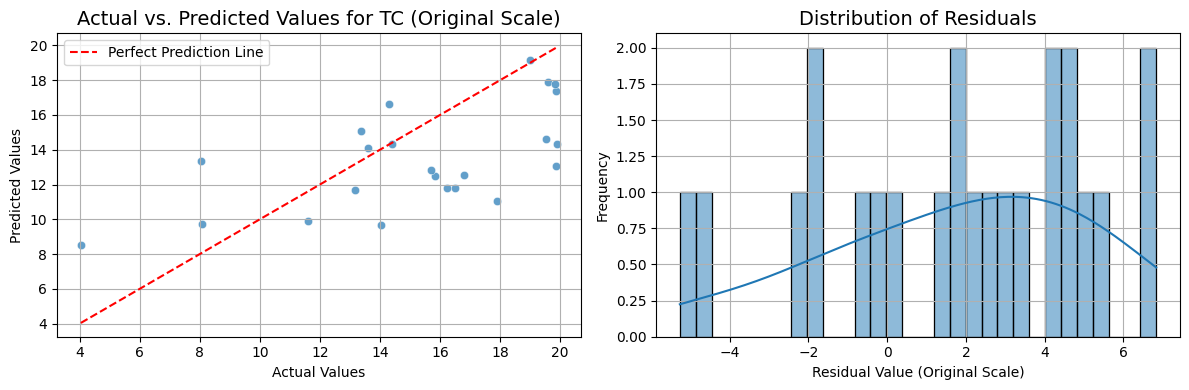


Function 'train_and_evaluate_ElasticNet' executed in 36 seconds.
Model saved successfully.


In [ ]:
print("--- Third Stage: drop counter-intuitive and small coefficients features ---\n")

compute_and_print_vif(df_train_pool, linear_preprocessor_tc)

drop_features=['main_channel_slope', 'basin_area',  'developed_vs_undeveloped_ratio',
                'form_factor', 'basin_area', 'basin_slope' 'pct_developed']
ElasticNet_tc = train_and_evaluate_ElasticNet("tc",
                                  max_iter=30000,
                                  alphas = np.concat((np.linspace(0.2, 5, 50), np.array([0.3455]))),
                                  l1_ratio = np.concat((np.linspace(0.01, 0.1, 50), np.array([0.023636363636363636]))),
                                  drop_features=drop_features,
                                  display_coefficients=True,
                                  display_test_on_test_set=True)
save_model(ElasticNet_tc, 'elasticnet_tc_watershed_only.joblib')

### Analysis of the Final (Third-Stage) Elastic Net Model for Target: $T_c$

This section evaluates the final Elastic Net model, which resulted from a third stage of fine-tuning where features with previously identified counter-intuitive or small coefficients were manually removed. This model is compared against the previous Elastic Net Model where data were grouped by year and watershed, to assess the impact of this model with refinement and data aggreagation over all the year for each watershed.


#### Model Performance: A Significant Decrease in Accuracy

The attempt to create a more parsimonious and physically plausible model by manually dropping features resulted in a **significant degradation of predictive performance**.

The final model achieved an **R-squared of only 0.199** on the original scale of the hold-out test set. This is a substantial drop from the **0.345 R-squared** achieved by the previous Elastic Net model. While the RMSE saw a minor improvement to **3.75 hours** (down from 4.11 hours), the sharp decrease in R-squared indicates that the model has lost a significant amount of its ability to explain the variance in the time of concentration.

This outcome demonstrates that the shrinkage of data points, not taking into consideration variation in land use, were contributing to the previous model's predictive power.


#### Interpretation of Coefficients: Persistent Inconsistencies

Despite the goal of improving interpretability, the final model still produced several coefficients that are **hydrologically counter-intuitive**.

* The coefficients for **`pct_developed` (+0.043)** and **`basin_slope` (+0.034)** remain positive, incorrectly implying that increased urbanization and steeper slopes slow down a watershed's response time.
* The coefficient for **`centroidal_flowpath` (-0.024)** is negative, which is physically implausible as a longer flow path should increase, not decrease, the time of concentration.

While the model did correctly identify some relationships (e.g., steeper `flowpath_1085_slope` and more `pct_barren` lead to faster responses), the persistence of these incorrect signs indicates that the linear framework is fundamentally unable to resolve the complex, correlated effects in the dataset.


#### Overall Conclusion and Comparison

This new approached of data aggregation **did not result in a better model**. By aggregating data not considering the effect of land use change, we created a model that less accurate and still contains physically inconsistent relationships.

Therefore, the **previous approach, for the Elastic Net model remains the superior linear model** for this problem. It provided a better balance of predictive performance (R² ≈ 0.35) and stability. This exercise confirms that the complex interactions within the dataset are not easily simplified and reinforces the conclusion that a linear framework is insufficient (or data needs to be further processed to incrase linearity).

### Elastic Net $R$

In [ ]:
# First Stage
print("First Stage: coarse search for optimum parameters")
_ = train_and_evaluate_ElasticNet("r",
                                  alphas =  [0.01, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5, 7, 10])

First Stage: coarse search for optimum parameters

--- Fitting ElasticNetCV Model on R... ---
     Parameters:
        alpha: [0.01, 0.1, 0.2, 0.3, 0.5, 1, 2, 3, 5, 7, 10]
        l1_ratio: [0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0]

    Training is complete.

--- Best Parameters ---
    alpha: 0.3
    l1_ratio: 0.1
    CV RMSE: 0.034

Function 'train_and_evaluate_ElasticNet' executed in 2 seconds.


In [ ]:
print("--- Second Stage: fine-grained search for optimum parameters ---")

_ = train_and_evaluate_ElasticNet("r",
                                  max_iter=30000,
                                  alphas = np.linspace(0.1, 0.5, 30),
                                  l1_ratio = np.linspace(0.01, 0.9, 50),
                                  display_coefficients=True)

--- Second Stage: fine-grained search for optimum parameters ---

--- Fitting ElasticNetCV Model on R... ---
     Parameters:
        alpha: [0.1        0.1137931  0.12758621 0.14137931 0.15517241 0.16896552
 0.18275862 0.19655172 0.21034483 0.22413793 0.23793103 0.25172414
 0.26551724 0.27931034 0.29310345 0.30689655 0.32068966 0.33448276
 0.34827586 0.36206897 0.37586207 0.38965517 0.40344828 0.41724138
 0.43103448 0.44482759 0.45862069 0.47241379 0.4862069  0.5       ]
        l1_ratio: [0.01       0.02816327 0.04632653 0.0644898  0.08265306 0.10081633
 0.11897959 0.13714286 0.15530612 0.17346939 0.19163265 0.20979592
 0.22795918 0.24612245 0.26428571 0.28244898 0.30061224 0.31877551
 0.33693878 0.35510204 0.37326531 0.39142857 0.40959184 0.4277551
 0.44591837 0.46408163 0.4822449  0.50040816 0.51857143 0.53673469
 0.55489796 0.57306122 0.59122449 0.60938776 0.62755102 0.64571429
 0.66387755 0.68204082 0.70020408 0.71836735 0.73653061 0.75469388
 0.77285714 0.79102041 0.80918367 0.8

#### Analysis and  Third-Stage Tuning (Target: $R$)

The second-stage Elastic Net model for the storage coefficient ($R$) was stabilized using a strong L2 (Ridge) regularization (`l1_ratio`: 0.01). While this prevented the extreme coefficient instability seen in simpler models, the resulting coefficients reveal a model that is **not hydrologically sound**. It fails to capture many of the fundamental physical relationships governing watershed storage.

The following features are removed in the third stage. However, it should be noted that the persistence of these issues even after regularization suggests that a linear modeling framework is likely insufficient for this target variable.


##### Recommended Features to Drop

* **Features with Counter-intuitive Coefficients:**
    The model assigns several coefficients with signs that contradict established hydrologic principles. These should be removed to test if a more plausible model can be found.
    - **`pct_forest` & `pct_wetlands`**: Both have negative coefficients, incorrectly implying that forests and wetlands *decrease* storage.
    - **`basin_relief`**: Its positive coefficient incorrectly suggests that steeper, high-relief watersheds have *more* storage.
    - **`drainage_density`**: Its positive coefficient incorrectly implies that a more efficient drainage network *increases* storage.
    - **`basin_area` & `basin_length`**: Their negative coefficients incorrectly suggest that larger, longer watersheds have *less* storage.
    - **`pct_water`**: Its negative coefficient incorrectly implies open water bodies *decrease* storage.

* **Features with Small Coefficients:**
    These features have a negligible impact on the model's predictions and can be removed to simplify the final model.
    - **`stream_length`** (Abs_Coeff: 0.002)
    - **`flowpath_1085_slope`** (Abs_Coeff: 0.003)
    - **`developed_vs_undeveloped_ratio`** (Abs_Coeff: 0.008)
    - **`main_channel_slope`** (Abs_Coeff: 0.018)

--- Third Stage: drop counter-intuitive and small coefficients features ---

--- Fitting ElasticNetCV Model on R... ---
     Parameters:
        alpha: [0.1        0.1137931  0.12758621 0.14137931 0.15517241 0.16896552
 0.18275862 0.19655172 0.21034483 0.22413793 0.23793103 0.25172414
 0.26551724 0.27931034 0.29310345 0.30689655 0.32068966 0.33448276
 0.34827586 0.36206897 0.37586207 0.38965517 0.40344828 0.41724138
 0.43103448 0.44482759 0.45862069 0.47241379 0.4862069  0.5       ]
        l1_ratio: [0.01       0.02816327 0.04632653 0.0644898  0.08265306 0.10081633
 0.11897959 0.13714286 0.15530612 0.17346939 0.19163265 0.20979592
 0.22795918 0.24612245 0.26428571 0.28244898 0.30061224 0.31877551
 0.33693878 0.35510204 0.37326531 0.39142857 0.40959184 0.4277551
 0.44591837 0.46408163 0.4822449  0.50040816 0.51857143 0.53673469
 0.55489796 0.57306122 0.59122449 0.60938776 0.62755102 0.64571429
 0.66387755 0.68204082 0.70020408 0.71836735 0.73653061 0.75469388
 0.77285714 0.79102041 0.8

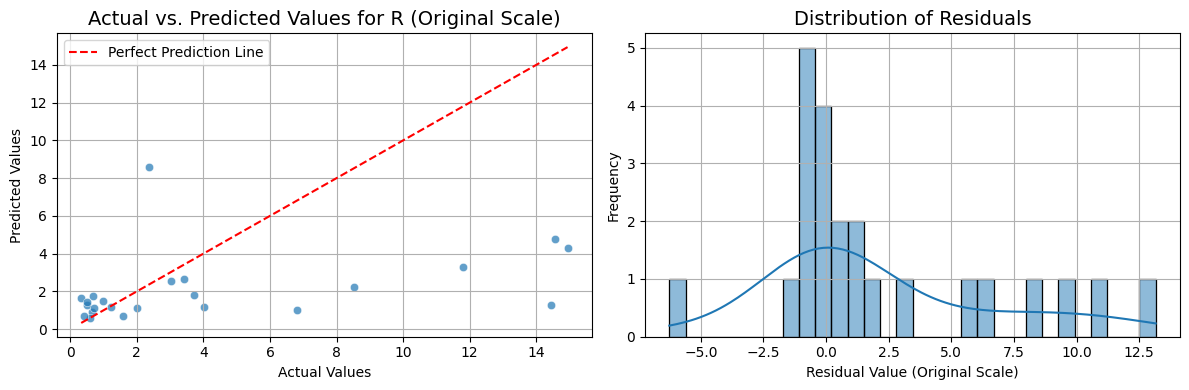


Function 'train_and_evaluate_ElasticNet' executed in 23 seconds.
Model saved successfully.


In [ ]:
print("--- Third Stage: drop counter-intuitive and small coefficients features ---")
drop_features = ['main_channel_slope', 'pct_forest', 'pct_wetlands', 'basin_relief', 'drainage_density', 'basin_area',
                 'basin_length', 'pct_water', 'stream_length', 'flowpath_1085_slope', 'developed_vs_undeveloped_ratio',
                 'main_channel_slope']
ElasticNet_r = train_and_evaluate_ElasticNet("r",
                                  max_iter=30000,
                                  alphas = np.linspace(0.1, 0.5, 30),
                                  l1_ratio = np.linspace(0.01, 0.9, 50),
                                  drop_features=drop_features,
                                  display_coefficients=True,
                                  display_test_on_test_set=True)
save_model(ElasticNet_r, 'elasticnet_r_watershed_only.joblib')

### Analysis of Final Elastic Net Model for Target: R

This analysis evaluates the final, refined Elastic Net model for the storage coefficient ($R$), trained on the simplified dataset where all watersheds are aggregated by a long-term average. The results are compared against the previous model trained on the hybrid (yearly/overall) dataset.

---
#### Overall Model Performance: No Improvement Found

The central hypothesis of this new approach was that a simpler, overall-aggregated dataset would reduce noise and improve model performance. **This hypothesis is not supported by the results.**

The final model's performance on the hold-out test set is exceptionally poor, achieving a **negative R-squared of -0.057** on the original scale. This indicates a complete failure to generalize, with predictions being less accurate than a simple mean-based estimate. This result is comparable to, and slightly worse than, the previous model's already poor performance (R² ≈ 0.056).

The significant drop from the log-scale R-squared (0.244) to the negative original-scale R-squared confirms a critical weakness seen in both approaches: the model is incapable of accurately predicting the high-magnitude values of $R$ that reside in the long right tail of its skewed distribution. These large errors are amplified by the exponential back-transformation, leading to the overall model failure.


#### Interpretation of Model Coefficients

The refined model, despite its poor performance, produced a set of coefficients that are arguably more hydrologically consistent than the previous attempt. Regularization has helped stabilize the model to find some plausible relationships.

* **Hydrologically Consistent Predictors:** The model correctly identifies that storage ($R$) is reduced by `pct_barren` land, steeper `basin_slope`, and a more compact shape (`compactness_coefficient`, `elongation_ratio`). It also correctly finds that storage increases with higher `sinuosity`.

* **Remaining Inconsistencies:** The model still contains hydrologically questionable coefficients, most notably a positive coefficient for **`relief_ratio`**, which incorrectly implies that steeper watersheds have more storage. This persistent issue across both modeling approaches points to the fundamental limitations of a linear framework.

#### Comparison and Overall Conclusion

Neither modeling approach—using the hybrid yearly data nor the simplified overall-aggregated data—was successful in creating a predictive model for the storage coefficient $R$. Both models failed completely on the hold-out test set.

While the model trained on the simplified (overall-aggregated) data produced a slightly more interpretable set of coefficients, this came at no benefit to its predictive power. The consistent failure across both datasets strongly suggests that the issue is not merely noise from the data aggregation strategy.

Instead, it is highly probable that the static geomorphological and land use features available in this dataset **do not contain sufficient predictive information** to model the complex, dynamic nature of the storage coefficient ($R$), or the data have too much noise. The skewed distribution of $R$ and the model's inability to predict high-magnitude values indicate that this parameter is even more complex to model, when compared to Tc and that other factors not taken into account in these dataset set might be influencing its variation.

# Conclusion

The objective of this notebook was to test the hypothesis that **aggregating data yearly** have added more noise than signal. However, it is observed a signifcant decrease in model perfomance for the $T_c$ parameter and still poor perfomance for $R$, for the *Elastic Net*. That showes that aggreating data yearly actually provided enough signal to improve model perfomance for $Tc$. No meaningful change was observed for $R$, confirming the challenges in modeling the Storage Coefficient of Modclark parameters.

Since, the perfomance deacrease for the best model of previous steps, **Elastic Net**, we don't see any reason for further analysis with more complex model like Random Forest that did not perfomed as good as Elastic Net.